# 🧰 ML Project Template — From a Table to a Tested Model Service

> **What this is:** a copy-and-fill starter notebook for a **new** tabular machine-learning project (data that fits in a table: one row per prediction). Every decision is a `# TODO(you):` marker with a sensible default. As shipped, it runs end to end on a real credit-risk dataset, so you can watch every step work before you change anything.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate |
| **Time** | under a minute to run, ~30 minutes to read; 1–2 days to adapt to a real project |
| **Prerequisites** | [End-to-End ML Project](../13_Capstone_Projects/01_End_to_End_ML_Project.ipynb) (the full worked example behind this template) · [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · pandas 3.0 · optuna 5.0 · FastAPI 0.141 · Pydantic 2.13 · pytest 9 · MLflow 3.16 (optional) |
| **Interview relevance** | ⭐⭐⭐ High — take-home assignments and "walk me through your ML workflow": leakage-free splits, model selection, threshold choice, calibration, honest test scores, shipping |

**Example data:** [German Credit (`credit-g`, OpenML 31)](https://www.openml.org/d/31) — 1,000 real loan applicants, 20 mixed numeric and categorical columns, target `class` = `good` / `bad` credit risk. It ships with a famous **cost matrix**: approving a bad applicant costs 5× more than rejecting a good one. That makes it a perfect stand-in for any "act or don't act" business problem.

## 🗺️ How to Use This Template

1. **Copy it** into your project folder and give it a real name, e.g. `my_project/01_loan_default_model.ipynb`. Keep the original untouched.
2. **Run it once unchanged** (*Kernel → Restart & Run All*). It downloads ~100 KB and finishes in about two minutes. Now you know every cell works.
3. **Fill in the TODOs top to bottom.** Search for `TODO(you)`. Most decisions live in **Step 1 (`CONFIG`)** and **Step 2 (loading)**; later steps read `CONFIG`, so they adapt on their own. Re-run from the top after each change.
4. **Delete what you don't need:**

| Delete… | …when |
|---|---|
| the "Example data" paragraph above and the credit-g notes in markdown cells | always, once your data is in |
| Step 9 (Optuna) | you have no time budget for tuning, or defaults already meet the goal |
| Steps 10–11 | regression tasks (they skip themselves anyway) |
| Step 15 | the model is served from a separate service repository (keep the tests idea!) |
| Step 16 | your team doesn't use MLflow |

5. **Tick the ✅ Checklist** at the end before anyone uses the model.

**Guardrails already built in** (the mistakes the capstone project fixed, so you don't repeat them):

| Classic mistake | Where this template prevents it |
|---|---|
| preprocessing fitted on all data (leakage) | Step 5: everything that learns lives inside one `Pipeline`, fitted on training folds only |
| wrong split for grouped or time-ordered data | Step 4: split switch + matching cross-validation folds |
| tuning breaks when a different model wins | Step 7: every model carries its **own** search space, smoke-tested |
| decision threshold tuned on the test set | Step 10: threshold chosen on **validation** from business costs |
| test set used again and again | Step 12: scored **once**, with confidence intervals, and a counter that warns on re-runs |
| API hard-codes the threshold | Steps 14–15: threshold saved in metadata; the service and its tests read it from there |

The full worked example with a package, Docker, CI, and monitoring is the [End-to-End ML Project](../13_Capstone_Projects/01_End_to_End_ML_Project.ipynb).

## 1. Setup and the `CONFIG` Cell 🟢

The first cell imports everything and prints versions (paste them into bug reports). The second cell is **the only place you should need to type project decisions**. A single `CONFIG` dictionary makes a notebook easy to review ("what did we decide?") and easy to turn into a script later (`CONFIG` becomes a YAML file or command-line flags).

In [1]:
# %pip install -q "scikit-learn>=1.9,<2" "pandas>=3.0,<4" "optuna>=5,<6" "fastapi>=0.141,<1" "pydantic>=2.13,<3" "httpx>=0.28" "pytest>=9" joblib matplotlib threadpoolctl
# Optional: %pip install -q "mlflow>=3.16,<4"

import hashlib
import importlib.metadata as md
import importlib.util
import json
import logging
import os
import platform
import re
import shutil
import subprocess
import sys
import textwrap
import time
from datetime import UTC, datetime
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")   # MLflow 3.16 prints a long hint (with local paths) on import

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier,
                              RandomForestRegressor)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (average_precision_score, brier_score_loss, get_scorer, mean_absolute_error, r2_score,
                             roc_auc_score, root_mean_squared_error)
from sklearn.model_selection import (GroupKFold, GroupShuffleSplit, KFold, StratifiedKFold, TimeSeriesSplit,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from threadpoolctl import threadpool_limits

threadpool_limits(limits=4)              # a busy laptop runs gradient boosting faster with a few threads than with one per core
pd.set_option("display.precision", 4)
NOTEBOOK_DIR = Path.cwd()
HAS_OPTUNA = importlib.util.find_spec("optuna") is not None
HAS_MLFLOW = importlib.util.find_spec("mlflow") is not None

versions = {pkg: md.version(pkg) for pkg in ["scikit-learn", "pandas", "numpy", "fastapi", "pydantic", "pytest"]}
versions |= {pkg: (md.version(pkg) if importlib.util.find_spec(pkg) else "not installed") for pkg in ["optuna", "mlflow"]}
print(f"Python {platform.python_version()} | " + " | ".join(f"{k} {v}" for k, v in versions.items()))


def rel(text):
    """Show paths relative to this notebook and never print the local home folder."""
    text = str(text).replace(str(NOTEBOOK_DIR) + os.sep, "").replace(str(NOTEBOOK_DIR), ".")
    return text.replace(str(Path.home()), "~")


def frame_sha256(frame: pd.DataFrame) -> str:
    """Content hash of a DataFrame (values + column names): proves which data a model saw."""
    digest = hashlib.sha256(pd.util.hash_pandas_object(frame, index=True).to_numpy().tobytes())
    digest.update(",".join(map(str, frame.columns)).encode())
    return digest.hexdigest()

Python 3.12.11 | scikit-learn 1.9.1 | pandas 3.0.5 | numpy 2.5.3 | fastapi 0.141.1 | pydantic 2.13.5 | pytest 9.1.1 | optuna 5.0.0 | mlflow 3.16.0


In [2]:
CONFIG = {
    # ── project ────────────────────────────────────────────────────────────────
    "project_name": "credit_risk",               # TODO(you): short snake_case name, used in file names and MLflow
    "model_version": "0.1.0",                    # TODO(you): bump for every release; a data/params fingerprint is appended
    "output_dir": Path("_outputs") / "ml_template",  # TODO(you): keep it git-ignored (artifacts, splits, service stub)
    # ── data (Step 2) ──────────────────────────────────────────────────────────
    "data_source": "openml",                     # TODO(you): "csv" | "parquet" | "openml"
    "data_path": None,                           # TODO(you): path to your CSV/Parquet file when data_source is a file
    "openml_name": "credit-g", "openml_version": 1,
    "target": "class",                           # TODO(you): the column to predict
    "task": "binary",                            # TODO(you): "binary" | "regression" (multiclass: see the Checklist)
    "positive_label": "bad",                     # TODO(you): binary only — the class you ACT on (fraud, churn, default)
    "drop_columns": [],                          # TODO(you): IDs, free text, and anything known only AFTER prediction time (leakage!)
    "numeric_features": None,                    # TODO(you): None = infer from dtypes in Step 3; list columns explicitly for production
    "categorical_features": None,
    # ── split (Step 4) ─────────────────────────────────────────────────────────
    "split_strategy": "stratified",              # TODO(you): "random" | "stratified" | "group" | "time"
    "group_column": None,                        # TODO(you): e.g. "customer_id" when one entity has many rows
    "time_column": None,                         # TODO(you): e.g. "application_date" when the model will predict the future
    "val_size": 0.2, "test_size": 0.2,
    "cv_folds": 5,
    # ── metrics and decision (Steps 8–12) ─────────────────────────────────────
    "primary_metric": "roc_auc",                 # TODO(you): a scikit-learn scorer name; regression e.g. "neg_root_mean_squared_error"
    "cost_false_positive": 1.0,                  # TODO(you): binary — cost of acting on a negative (rejecting a good applicant)
    "cost_false_negative": 5.0,                  # TODO(you): binary — cost of missing a positive (approving a bad applicant)
    # ── tuning, calibration, tracking (Steps 9, 11, 16) ───────────────────────
    "tune": True,                                # TODO(you): False to skip Optuna
    "n_trials": 25, "tuning_timeout_s": 120,
    "calibration": None,                         # TODO(you): None | "sigmoid" | "isotonic" — decide after reading Step 11
    "use_mlflow": True,                          # TODO(you): logs a run in Step 16 when MLflow is installed
    "n_bootstrap": 1000,
    "seed": 42,
}

# Fail fast on inconsistent settings, before any expensive work.
assert CONFIG["task"] in {"binary", "regression"}, "task must be 'binary' or 'regression'"
assert CONFIG["split_strategy"] in {"random", "stratified", "group", "time"}
assert not (CONFIG["split_strategy"] == "stratified" and CONFIG["task"] == "regression"), "stratify needs classes: use 'random' (or 'time'/'group')"
assert CONFIG["split_strategy"] != "group" or CONFIG["group_column"], "split_strategy 'group' needs group_column"
assert CONFIG["split_strategy"] != "time" or CONFIG["time_column"], "split_strategy 'time' needs time_column"
get_scorer(CONFIG["primary_metric"])            # raises for an unknown scorer name
SEED = CONFIG["seed"]
OUT = CONFIG["output_dir"]
OUT.mkdir(parents=True, exist_ok=True)
IS_BINARY = CONFIG["task"] == "binary"
print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=1))

{
 "project_name": "credit_risk",
 "model_version": "0.1.0",
 "output_dir": "_outputs/ml_template",
 "data_source": "openml",
 "data_path": "None",
 "openml_name": "credit-g",
 "openml_version": "1",
 "target": "class",
 "task": "binary",
 "positive_label": "bad",
 "drop_columns": "[]",
 "numeric_features": "None",
 "categorical_features": "None",
 "split_strategy": "stratified",
 "group_column": "None",
 "time_column": "None",
 "val_size": "0.2",
 "test_size": "0.2",
 "cv_folds": "5",
 "primary_metric": "roc_auc",
 "cost_false_positive": "1.0",
 "cost_false_negative": "5.0",
 "tune": "True",
 "n_trials": "25",
 "tuning_timeout_s": "120",
 "calibration": "None",
 "use_mlflow": "True",
 "n_bootstrap": "1000",
 "seed": "42"
}


> 💡 **Interview angle:** "How do you keep experiments reproducible?" — one config object (seed, splits, metric, costs) saved next to the model, data hashes in the metadata, pinned library versions, and code in git. Anyone can rerun and get the same model version.

## 2. Data Loading Adapter 🟢

An **adapter** is a small function that hides *where* the data comes from. Everything after it only sees one `DataFrame` with **one row per prediction you'll make** and the target column included. Swap the source (CSV today, a warehouse query tomorrow) without touching the rest.

Only do **row-wise** cleaning here (fix types, strip spaces, parse dates). Anything that **learns** from data, like the median used to fill gaps, belongs in the Step 5 pipeline, or it leaks test information into training.

In [3]:
def load_data(config: dict) -> pd.DataFrame:
    source = config["data_source"]
    if source == "csv":
        df = pd.read_csv(config["data_path"])            # TODO(you): add dtype={...} and parse_dates=[...] for your columns
    elif source == "parquet":
        df = pd.read_parquet(config["data_path"])
    elif source == "openml":
        from sklearn.datasets import fetch_openml
        df = fetch_openml(config["openml_name"], version=config["openml_version"], as_frame=True).frame   # cached after the first download
    else:
        raise NotImplementedError(f"TODO(you): add a loader for data_source={source!r} (e.g. a SQL query with pd.read_sql)")
    # TODO(you): row-wise fixes only, e.g. df["amount"] = pd.to_numeric(df["amount"].str.replace(",", ""), errors="coerce")
    return df.drop(columns=config["drop_columns"])


start = time.perf_counter()
df = load_data(CONFIG)
DATA_SHA256 = frame_sha256(df)
print(f"loaded {df.shape[0]:,} rows × {df.shape[1]} columns in {time.perf_counter() - start:.1f} s | sha256 {DATA_SHA256[:16]}…")
print("target distribution:", df[CONFIG["target"]].value_counts(dropna=False).to_dict() if IS_BINARY else df[CONFIG["target"]].describe().round(3).to_dict())
df.head(3)

loaded 1,000 rows × 21 columns in 0.1 s | sha256 f55735545b61944b…
target distribution: {'good': 700, 'bad': 300}


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good


## 3. Schema and Data-Quality Checks 🟢

A model trained on broken data fails **silently**: it still produces numbers. So we check the table against a **schema** (which columns, which types, which roles) and a few quality rules. **Errors** stop the notebook; **warnings** are printed for you to judge.

We deliberately don't look at feature–target relationships yet. That needs the split first (Step 4), so nothing is learned from test rows.

In [4]:
TARGET = CONFIG["target"]
SPLIT_COLUMNS = {c for c in (CONFIG["group_column"], CONFIG["time_column"]) if c}     # used to split, never as features
feature_columns = [c for c in df.columns if c != TARGET and c not in SPLIT_COLUMNS]
NUMERIC = CONFIG["numeric_features"] or df[feature_columns].select_dtypes("number").columns.tolist()
CATEGORICAL = CONFIG["categorical_features"] or [c for c in feature_columns if c not in NUMERIC]
FEATURES = NUMERIC + CATEGORICAL
ignored = sorted(set(feature_columns) - set(FEATURES))

errors, warnings_found = [], []
errors += [f"split column {c!r} is missing" for c in SPLIT_COLUMNS if c not in df.columns]
if TARGET not in df.columns:
    errors.append(f"target column {TARGET!r} is missing")
elif df[TARGET].isna().any():
    errors.append(f"{int(df[TARGET].isna().sum())} rows have no target — drop or label them in load_data()")
if IS_BINARY and TARGET in df.columns:
    labels = set(df[TARGET].dropna().unique())
    if len(labels) != 2 or CONFIG["positive_label"] not in labels:
        errors.append(f"binary task needs exactly 2 classes including positive_label {CONFIG['positive_label']!r}; found {sorted(map(str, labels))}")
for column in NUMERIC:
    if not pd.api.types.is_numeric_dtype(df[column]):
        errors.append(f"numeric feature {column!r} has dtype {df[column].dtype} — convert it in load_data()")
missing_share = df[FEATURES].isna().mean()
warnings_found += [f"{c!r} is {s:.0%} missing" for c, s in missing_share.items() if s > 0.4]
warnings_found += [f"{c!r} is constant (useless)" for c in FEATURES if df[c].nunique(dropna=False) <= 1]
warnings_found += [f"{c!r} looks like an ID (every value unique) — drop it" for c in FEATURES if df[c].nunique() == len(df)]
warnings_found += [f"{c!r} has {df[c].nunique()} categories — consider grouping rare ones" for c in CATEGORICAL if df[c].nunique() > 50]
if (n_dup := int(df.duplicated().sum())):
    warnings_found.append(f"{n_dup} duplicate rows — duplicates across splits inflate scores")
if ignored:
    warnings_found.append(f"columns not used as features: {ignored}")

schema = pd.DataFrame({"dtype": df[FEATURES].dtypes.astype(str), "role": ["numeric" if c in NUMERIC else "categorical" for c in FEATURES],
                       "missing": missing_share, "n_unique": df[FEATURES].nunique()})
print(schema.to_string(), "\n")
print(f"{len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical features | errors: {len(errors)} | warnings: {len(warnings_found)}")
for message in warnings_found:
    print("  ⚠️", message)
for message in errors:
    print("  ❌", message)
if errors:
    raise ValueError("data-quality errors above — fix them before modelling")
print("✅ schema checks passed")

                           dtype         role  missing  n_unique
duration                   int64      numeric      0.0        33
credit_amount              int64      numeric      0.0       921
installment_commitment     int64      numeric      0.0         4
residence_since            int64      numeric      0.0         4
age                        int64      numeric      0.0        53
existing_credits           int64      numeric      0.0         4
num_dependents             int64      numeric      0.0         2
checking_status         category  categorical      0.0         4
credit_history          category  categorical      0.0         5
purpose                 category  categorical      0.0        10
savings_status          category  categorical      0.0         5
employment              category  categorical      0.0         5
personal_status         category  categorical      0.0         4
other_parties           category  categorical      0.0         3
property_magnitude      c

> 💡 **Interview angle:** "How do you make a pipeline robust to bad data?" — validate every batch against a schema (columns, types, allowed values, ranges) and business rules, fail fast on errors, and run the **same** validation in training and serving. Pandera or Great Expectations do this at scale.

## 4. Split Strategy Switch 🟡

**Leakage** = information from the evaluation data sneaking into training, so scores look better than reality. The split must copy how the model will be used:

| `split_strategy` | Use when | Cross-validation folds |
|---|---|---|
| `random` | rows are independent (regression, balanced labels) | `KFold` |
| `stratified` | classification: every split keeps the class ratio | `StratifiedKFold` |
| `group` | one entity (customer, patient, device) has several rows: an entity must never be in two splits | `GroupKFold` |
| `time` | you'll predict the future: train on the past, validate and test on later periods | `TimeSeriesSplit` |

Three splits, each with **one job**: **train** (fit + cross-validation + tuning), **validation** (threshold, calibration, explanations), **test** (one final honest estimate).

In [5]:
def split_data(frame: pd.DataFrame, config: dict) -> dict[str, pd.DataFrame]:
    strategy, seed = config["split_strategy"], config["seed"]
    test_size, val_size = config["test_size"], config["val_size"]
    if strategy in ("random", "stratified"):
        stratify = frame[TARGET] if strategy == "stratified" else None
        train_val, test = train_test_split(frame, test_size=test_size, stratify=stratify, random_state=seed)
        stratify = train_val[TARGET] if strategy == "stratified" else None
        train, val = train_test_split(train_val, test_size=val_size / (1 - test_size), stratify=stratify, random_state=seed)
    elif strategy == "group":
        groups = frame[config["group_column"]]
        train_val_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed).split(frame, groups=groups))
        train_val, test = frame.iloc[train_val_idx], frame.iloc[test_idx]
        train_idx, val_idx = next(GroupShuffleSplit(n_splits=1, test_size=val_size / (1 - test_size), random_state=seed)
                                  .split(train_val, groups=train_val[config["group_column"]]))
        train, val = train_val.iloc[train_idx], train_val.iloc[val_idx]
    else:  # time: sort, then cut — no shuffling, ever
        ordered = frame.sort_values(config["time_column"], kind="stable")
        n_test, n_val = round(len(frame) * test_size), round(len(frame) * val_size)
        train, val, test = ordered.iloc[:-(n_test + n_val)], ordered.iloc[-(n_test + n_val):-n_test], ordered.iloc[-n_test:]
    return {"train": train, "validation": val, "test": test}


def make_cv(config: dict):
    """Cross-validation folds that match the split strategy (used for baseline, comparison, tuning, calibration)."""
    k, seed = config["cv_folds"], config["seed"]
    return {"random": KFold(k, shuffle=True, random_state=seed), "stratified": StratifiedKFold(k, shuffle=True, random_state=seed),
            "group": GroupKFold(k), "time": TimeSeriesSplit(k)}[config["split_strategy"]]


def to_xy(frame: pd.DataFrame):
    y = (frame[TARGET] == CONFIG["positive_label"]).astype(int) if IS_BINARY else frame[TARGET].astype(float)
    return frame[FEATURES], y


splits = split_data(df, CONFIG)
X_train, y_train = to_xy(splits["train"])
X_val, y_val = to_xy(splits["validation"])
X_test, y_test = to_xy(splits["test"])            # 🔒 locked until Step 12
CV = make_cv(CONFIG)
CV_GROUPS = splits["train"][CONFIG["group_column"]] if CONFIG["split_strategy"] == "group" else None

# Leakage assertions for the chosen strategy
index_sets = {name: set(frame.index) for name, frame in splits.items()}
assert not (index_sets["train"] & index_sets["validation"] or index_sets["train"] & index_sets["test"] or index_sets["validation"] & index_sets["test"])
if CONFIG["split_strategy"] == "group":
    group_sets = {name: set(frame[CONFIG["group_column"]]) for name, frame in splits.items()}
    assert not (group_sets["train"] & group_sets["validation"] or group_sets["train"] & group_sets["test"] or group_sets["validation"] & group_sets["test"])
if CONFIG["split_strategy"] == "time":
    tc = CONFIG["time_column"]
    assert splits["train"][tc].max() <= splits["validation"][tc].min() and splits["validation"][tc].max() <= splits["test"][tc].min()

(OUT / "splits").mkdir(exist_ok=True)
SPLIT_HASHES = {}
for name, frame in splits.items():
    pd.Series(frame.index, name="row_index").to_csv(OUT / "splits" / f"{name}_rows.csv", index=False)   # which rows, for audits
    SPLIT_HASHES[name] = frame_sha256(frame)
summary = pd.DataFrame({name: {"rows": len(frame), ("positive rate" if IS_BINARY else "target mean"): to_xy(frame)[1].mean(),
                               "sha256": SPLIT_HASHES[name][:12] + "…"} for name, frame in splits.items()}).T
print(summary.to_string())
print(f"✅ '{CONFIG['split_strategy']}' split: no row{', group' if CONFIG['split_strategy'] == 'group' else ''} in two splits"
      + (" and time only moves forward" if CONFIG["split_strategy"] == "time" else "") + f" | CV folds: {type(CV).__name__}")

           rows positive rate         sha256
train       600           0.3  919f1aa19ad0…
validation  200           0.3  e0933cd3cd02…
test        200           0.3  2d356c1caeb6…
✅ 'stratified' split: no row in two splits | CV folds: StratifiedKFold


**Leakage scan (training rows only).** If one column alone predicts the target almost perfectly, it is usually a column filled in *after* the outcome (e.g. `days_overdue` for default prediction) or an ID. We score each column on its own: ROC-AUC of the raw value (numbers) or of the category's target rate (categories).

In [6]:
def single_feature_score(column: str) -> float:
    x, y = X_train[column], y_train
    values = x.map(y.groupby(x, observed=True).mean()).astype(float) if column in CATEGORICAL else x.astype(float)
    values = values.fillna(values.median())
    if IS_BINARY:
        auc = roc_auc_score(y, values)
        return max(auc, 1 - auc)
    return abs(pd.Series(values).corr(y, method="spearman"))


scan = pd.Series({c: single_feature_score(c) for c in FEATURES}).sort_values(ascending=False)
print(f"strongest single columns ({'ROC-AUC' if IS_BINARY else '|Spearman correlation|'} on train):")
print(scan.head(5).round(3).to_string())
suspects = scan[scan > 0.95]
print(f"⚠️ possible leakage — inspect how these are recorded: {suspects.index.tolist()}" if len(suspects)
      else "✅ no single column is suspiciously predictive (all ≤ 0.95)")

strongest single columns (ROC-AUC on train):
checking_status       0.680
duration              0.639
purpose               0.637
credit_history        0.636
property_magnitude    0.593
✅ no single column is suspiciously predictive (all ≤ 0.95)


> 💡 **Interview angle:** "Your model scores 0.99 AUC on day one. What do you check?" — leakage first: a feature recorded after the outcome, IDs, duplicates or the same entity across splits, a random split on time-ordered data, and preprocessing fitted before splitting.

## 5. Preprocessing `ColumnTransformer` 🟢

A `ColumnTransformer` applies different preparation to different columns, and lives **inside** the model `Pipeline`. Inside cross-validation it is re-fitted on each training fold, so fold statistics never leak. At serving time you pass raw columns and the pipeline does the rest: no second copy of feature code to drift out of sync (*training/serving skew*).

Two recipes, because models want different inputs:
- **`onehot`** for linear models, SVMs, k-NN, neural nets: fill gaps with the median, **scale** numbers, **one-hot encode** categories (rare ones grouped, unseen ones ignored).
- **`ordinal`** for tree models: categories → integer codes, numbers untouched (trees don't care about scale and handle missing values natively).

In [7]:
def make_preprocessor(kind: str) -> ColumnTransformer:
    if kind == "onehot":
        numeric = make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler())
        categorical = make_pipeline(SimpleImputer(strategy="most_frequent"),
                                    OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False))
        return ColumnTransformer([("num", numeric, NUMERIC), ("cat", categorical, CATEGORICAL)], verbose_feature_names_out=False)
    if kind == "ordinal":
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan, encoded_missing_value=np.nan)
        return ColumnTransformer([("num", "passthrough", NUMERIC), ("cat", encoder, CATEGORICAL)],
                                 verbose_feature_names_out=False).set_output(transform="pandas")
    # TODO(you): add domain features as a row-wise FunctionTransformer step BEFORE this transformer (see the capstone's FeatureAdder)
    raise ValueError(f"unknown preprocessor kind {kind!r}")


for kind in ("onehot", "ordinal"):
    transformed = make_preprocessor(kind).fit(X_train).transform(X_train.head(5))    # fitted on TRAIN only
    print(f"{kind:8s}: {X_train.shape[1]} raw columns → {transformed.shape[1]} model inputs")

onehot  : 20 raw columns → 59 model inputs
ordinal : 20 raw columns → 20 model inputs


## 6. Baseline 🟢

A **baseline** answers "is the model learning anything?" A dummy model that ignores the features (always predicts the base rate, or the mean for regression) gives the floor. We score it with the **same** folds and metric used for the real candidates.

In [8]:
SCORING = ({"roc_auc": "roc_auc", "average_precision": "average_precision", "neg_brier_score": "neg_brier_score", "neg_log_loss": "neg_log_loss"}
           if IS_BINARY else {"neg_root_mean_squared_error": "neg_root_mean_squared_error", "neg_mean_absolute_error": "neg_mean_absolute_error", "r2": "r2"})
SCORING[CONFIG["primary_metric"]] = CONFIG["primary_metric"]
PRIMARY = CONFIG["primary_metric"]


def cv_scores(pipeline, name: str) -> dict:
    result = cross_validate(pipeline, X_train, y_train, cv=CV, groups=CV_GROUPS, scoring=SCORING, return_train_score=True)
    row = {"model": name}
    for metric in SCORING:
        row[f"{metric}_mean"], row[f"{metric}_std"] = result[f"test_{metric}"].mean(), result[f"test_{metric}"].std()
    row["train_minus_cv"] = result[f"train_{PRIMARY}"].mean() - row[f"{PRIMARY}_mean"]    # large gap = overfitting
    row["fit_seconds"] = result["fit_time"].mean()
    return row


baseline = DummyClassifier(strategy="prior") if IS_BINARY else DummyRegressor(strategy="mean")
baseline_row = cv_scores(Pipeline([("model", baseline)]), "baseline_dummy")
print(f"baseline (ignores features): CV {PRIMARY} = {baseline_row[f'{PRIMARY}_mean']:.4f}")

baseline (ignores features): CV roc_auc = 0.5000


## 7. Model Registry With a Search Space per Model 🟡

The **registry** is a dictionary: model name → estimator, preprocessing recipe, and its **own hyperparameter search space**. Listing models from simplest to most complex lets Step 8 prefer the simpler one on a tie.

Why a search space *per model*? A common template bug: one shared space like `max_depth` and `n_estimators` works for trees, then crashes the day logistic regression wins. Here tuning always uses the winner's own space, and the smoke test below proves every space produces valid parameters.

Parameter names use the `step__param` convention: `model__C` means "parameter `C` of the pipeline step named `model`".

In [9]:
MODEL_REGISTRY = {
    "binary": {
        "logistic_regression": {
            "estimator": LogisticRegression(max_iter=5000), "preprocessor": "onehot",
            "space": lambda t: {"model__C": t.suggest_float("model__C", 1e-3, 1e2, log=True)},
        },
        "random_forest": {
            "estimator": RandomForestClassifier(n_estimators=300, n_jobs=2, random_state=SEED), "preprocessor": "ordinal",
            "space": lambda t: {"model__max_depth": t.suggest_int("model__max_depth", 3, 20),
                                "model__min_samples_leaf": t.suggest_int("model__min_samples_leaf", 1, 30),
                                "model__max_features": t.suggest_float("model__max_features", 0.2, 1.0)},
        },
        "hist_gradient_boosting": {
            "estimator": HistGradientBoostingClassifier(categorical_features=CATEGORICAL or None, random_state=SEED), "preprocessor": "ordinal",
            "space": lambda t: {"model__learning_rate": t.suggest_float("model__learning_rate", 0.01, 0.3, log=True),
                                "model__max_leaf_nodes": t.suggest_int("model__max_leaf_nodes", 7, 63),
                                "model__min_samples_leaf": t.suggest_int("model__min_samples_leaf", 5, 100),
                                "model__l2_regularization": t.suggest_float("model__l2_regularization", 1e-4, 10.0, log=True)},
        },
    },
    "regression": {
        "ridge": {
            "estimator": Ridge(), "preprocessor": "onehot",
            "space": lambda t: {"model__alpha": t.suggest_float("model__alpha", 1e-3, 1e3, log=True)},
        },
        "random_forest": {
            "estimator": RandomForestRegressor(n_estimators=300, n_jobs=2, random_state=SEED), "preprocessor": "ordinal",
            "space": lambda t: {"model__max_depth": t.suggest_int("model__max_depth", 3, 20),
                                "model__min_samples_leaf": t.suggest_int("model__min_samples_leaf", 1, 30),
                                "model__max_features": t.suggest_float("model__max_features", 0.2, 1.0)},
        },
        "hist_gradient_boosting": {
            "estimator": HistGradientBoostingRegressor(categorical_features=CATEGORICAL or None, random_state=SEED), "preprocessor": "ordinal",
            "space": lambda t: {"model__learning_rate": t.suggest_float("model__learning_rate", 0.01, 0.3, log=True),
                                "model__max_leaf_nodes": t.suggest_int("model__max_leaf_nodes", 7, 63),
                                "model__min_samples_leaf": t.suggest_int("model__min_samples_leaf", 5, 100),
                                "model__l2_regularization": t.suggest_float("model__l2_regularization", 1e-4, 10.0, log=True)},
        },
    },
}
CANDIDATES = MODEL_REGISTRY[CONFIG["task"]]     # TODO(you): add/remove models (e.g. XGBoost, LightGBM) — keep simplest first


def make_model_pipeline(name: str, params: dict | None = None) -> Pipeline:
    spec = CANDIDATES[name]
    pipeline = Pipeline([("preprocess", make_preprocessor(spec["preprocessor"])), ("model", clone(spec["estimator"]))])
    return pipeline.set_params(**(params or {}))


if HAS_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    smoke_study = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=SEED))
    for name, spec in CANDIDATES.items():
        for _ in range(3):                                         # 3 random draws from each space
            params = spec["space"](smoke_study.ask())
            make_model_pipeline(name, params).fit(X_train.head(200), y_train.head(200))   # set_params + fit validate names and values
        print(f"✅ {name:24s} search space OK → e.g. {params}")
else:
    print("⏭️ Skipped the search-space smoke test: optuna is not installed (pip install optuna).")

✅ logistic_regression      search space OK → e.g. {'model__C': 4.570563099801454}


✅ random_forest            search space OK → e.g. {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__max_features': 0.9759278817295955}
✅ hist_gradient_boosting   search space OK → e.g. {'model__learning_rate': 0.08012737503998542, 'model__max_leaf_nodes': 14, 'model__min_samples_leaf': 33, 'model__l2_regularization': 0.0067890532716984855}


## 8. Cross-Validation Comparison 🟡

Every candidate gets the **same folds on the training split**. We report the mean and spread of each metric, plus `train_minus_cv` (training score minus CV score; a big gap means overfitting).

**Selection rule — one standard error:** take the best mean score; any model within one standard error of it is "statistically tied", and among tied models we pick the **simplest** (first in the registry). Small score differences are noise at typical data sizes and don't pay for extra latency, maintenance, and harder explanations.

cross-validation of 3 models × 5 folds took 1.4 s
                        roc_auc_mean  average_precision_mean  neg_brier_score_mean  neg_log_loss_mean  roc_auc_std  train_minus_cv  fit_seconds
model                                                                                                                                          
baseline_dummy                0.5000                  0.3000                -0.210            -0.6109       0.0000          0.0000       0.0048
logistic_regression           0.7667                  0.5884                -0.176            -0.5314       0.0206          0.0910       0.0078
random_forest                 0.7741                  0.6278                -0.168            -0.5051       0.0268          0.2259       0.1140
hist_gradient_boosting        0.7735                  0.6144                -0.181            -0.5720       0.0351          0.2265       0.0616

SELECTED: logistic_regression is within one standard error (0.0120) of random_forest 

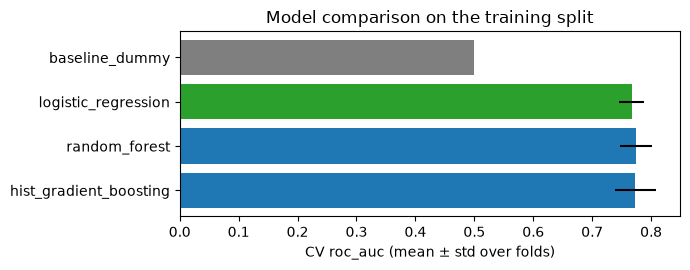

In [10]:
start = time.perf_counter()
cv_table = pd.DataFrame([baseline_row] + [cv_scores(make_model_pipeline(name), name) for name in CANDIDATES]).set_index("model")
print(f"cross-validation of {len(CANDIDATES)} models × {CONFIG['cv_folds']} folds took {time.perf_counter() - start:.1f} s")
shown = [f"{m}_mean" for m in SCORING] + [f"{PRIMARY}_std", "train_minus_cv", "fit_seconds"]
print(cv_table[shown].round(4).to_string())


def select_model(table: pd.DataFrame) -> tuple[str, str]:
    models = table.drop(index="baseline_dummy")
    best = models[f"{PRIMARY}_mean"].idxmax()
    standard_error = models.loc[best, f"{PRIMARY}_std"] / np.sqrt(CONFIG["cv_folds"])
    for name in models.index:                                                  # registry order = simplest first
        gap = models.loc[best, f"{PRIMARY}_mean"] - models.loc[name, f"{PRIMARY}_mean"]
        if gap <= standard_error:
            return name, (f"{name} has the best mean CV {PRIMARY}" if name == best else
                          f"{name} is within one standard error ({standard_error:.4f}) of {best} (gap {gap:.4f}) and is simpler")


SELECTED, SELECTION_REASON = select_model(cv_table)
lift = cv_table.loc[SELECTED, f"{PRIMARY}_mean"] - cv_table.loc["baseline_dummy", f"{PRIMARY}_mean"]
print(f"\nSELECTED: {SELECTION_REASON}\nlift over the dummy baseline: {lift:+.4f} {PRIMARY}")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(cv_table.index, cv_table[f"{PRIMARY}_mean"], xerr=cv_table[f"{PRIMARY}_std"],
        color=["tab:gray"] + ["tab:green" if n == SELECTED else "tab:blue" for n in CANDIDATES])
ax.set(xlabel=f"CV {PRIMARY} (mean ± std over folds)", title="Model comparison on the training split")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "How did you pick the model?" — identical CV folds for every candidate, a metric tied to the decision, a dummy baseline for context, and a tie-break toward simplicity (one-standard-error rule). Never pick on the test set.

## 9. Optional Optuna Tuning 🟡

**Optuna** tries hyperparameter combinations and learns which regions of the search space score well (its default TPE sampler). The objective is the **mean CV score on the training split** with the same folds, so the validation and test splits stay untouched.

Two honest details: the best-of-many CV score is **optimistic** (you picked the luckiest trial), so we only keep tuned parameters if they beat the defaults; and we tune only the **selected** model, using its own space from the registry.

The cell ends by fitting the **final pipeline** on the training split (optionally wrapped in probability calibration, see Step 11).

In [11]:
best_params, tuning_note = {}, "defaults (tuning skipped)"
if CONFIG["tune"] and HAS_OPTUNA:
    def objective(trial):
        params = CANDIDATES[SELECTED]["space"](trial)
        scores = cross_validate(make_model_pipeline(SELECTED, params), X_train, y_train, cv=CV, groups=CV_GROUPS, scoring=PRIMARY)["test_score"]
        return scores.mean()

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED), study_name=f"{CONFIG['project_name']}_{SELECTED}")
    start = time.perf_counter()
    study.optimize(objective, n_trials=CONFIG["n_trials"], timeout=CONFIG["tuning_timeout_s"])
    default_score = cv_table.loc[SELECTED, f"{PRIMARY}_mean"]
    print(f"{len(study.trials)} trials in {time.perf_counter() - start:.1f} s | default CV {PRIMARY} {default_score:.4f} → best trial {study.best_value:.4f}")
    print("best params:", {k: round(v, 5) if isinstance(v, float) else v for k, v in study.best_params.items()})
    if study.best_value > default_score:
        best_params, tuning_note = study.best_params, f"Optuna TPE, {len(study.trials)} trials, CV {PRIMARY} {study.best_value:.4f}"
        print("→ keeping the tuned parameters")
    else:
        tuning_note = f"Optuna found nothing better than defaults in {len(study.trials)} trials"
        print("→ tuning did not beat the defaults: keeping the defaults")
elif CONFIG["tune"]:
    print("⏭️ Skipped tuning: optuna is not installed (pip install optuna). Using default parameters.")
else:
    print("⏭️ Tuning disabled in CONFIG. Using default parameters.")

final_pipeline = make_model_pipeline(SELECTED, best_params)
if CONFIG["calibration"]:
    if not IS_BINARY or CONFIG["split_strategy"] in ("group", "time"):
        raise ValueError("TODO(you): calibration here supports binary tasks with random/stratified splits; for group/time data, "
                         "calibrate on a separate later period with CalibratedClassifierCV(FrozenEstimator(model))")
    final_model = CalibratedClassifierCV(final_pipeline, method=CONFIG["calibration"], cv=CV).fit(X_train, y_train)
else:
    final_model = final_pipeline.fit(X_train, y_train)
print(f"final model: {SELECTED} ({tuning_note}){' + ' + CONFIG['calibration'] + ' calibration' if CONFIG['calibration'] else ''}, fitted on {len(X_train):,} training rows")

25 trials in 1.2 s | default CV roc_auc 0.7667 → best trial 0.7731
best params: {'model__C': 0.10867}
→ keeping the tuned parameters
final model: logistic_regression (Optuna TPE, 25 trials, CV roc_auc 0.7731), fitted on 600 training rows


## 10. Threshold Selection on Validation 🟡

A classifier outputs a probability; the business needs a yes/no. The default 0.5 is almost never right when mistakes have different costs. We score the **validation** split, compute the **average cost per decision** for every threshold from 0.01 to 0.99, and keep the cheapest:

$$\text{cost}(t) = \frac{\text{FP}(t)\cdot c_{FP} + \text{FN}(t)\cdot c_{FN}}{n}$$

For perfectly calibrated probabilities theory says the best threshold is $c_{FP}/(c_{FP}+c_{FN})$; the empirical search works even when calibration isn't perfect. The test split is still locked.

best threshold on validation: 0.09 (theory for calibrated probabilities: 0.17)
cost per decision — threshold 0.09: 0.515 | threshold 0.50: 0.940 | act on nobody: 1.500 | act on everyone: 0.700
thresholds within 2% of the best cost: 0.09–0.25 → a wide, flat optimum: the exact value is noisy, so re-check it when validation data grows


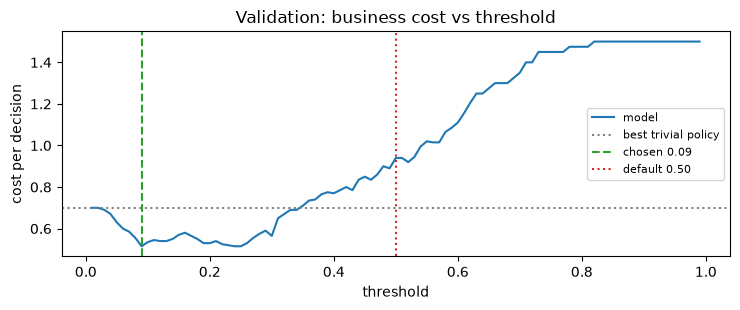

In [12]:
def decision_cost(y_true, act, c_fp=CONFIG["cost_false_positive"], c_fn=CONFIG["cost_false_negative"]) -> float:
    y_true, act = np.asarray(y_true), np.asarray(act, dtype=bool)
    return float(((act & (y_true == 0)).sum() * c_fp + (~act & (y_true == 1)).sum() * c_fn) / len(y_true))


THRESHOLD = None
if IS_BINARY:
    val_proba = final_model.predict_proba(X_val)[:, 1]
    grid = np.round(np.linspace(0.01, 0.99, 99), 2)
    costs = pd.Series([decision_cost(y_val, val_proba >= t) for t in grid], index=grid)
    THRESHOLD = float(costs.idxmin())
    theory = CONFIG["cost_false_positive"] / (CONFIG["cost_false_positive"] + CONFIG["cost_false_negative"])
    act_none, act_all = decision_cost(y_val, np.zeros(len(y_val))), decision_cost(y_val, np.ones(len(y_val)))
    print(f"best threshold on validation: {THRESHOLD:.2f} (theory for calibrated probabilities: {theory:.2f})")
    print(f"cost per decision — threshold {THRESHOLD:.2f}: {costs[THRESHOLD]:.3f} | threshold 0.50: {costs[0.5]:.3f} | "
          f"act on nobody: {act_none:.3f} | act on everyone: {act_all:.3f}")
    near_best = costs[costs <= costs.min() * 1.02].index
    width = near_best.max() - near_best.min()
    print(f"thresholds within 2% of the best cost: {near_best.min():.2f}–{near_best.max():.2f} → "
          + ("a wide, flat optimum: the exact value is noisy, so re-check it when validation data grows" if width >= 0.05
             else "a narrow optimum on this validation split"))

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ax.plot(costs.index, costs.values, label="model")
    ax.axhline(min(act_none, act_all), color="gray", ls=":", label="best trivial policy")
    ax.axvline(THRESHOLD, color="tab:green", ls="--", label=f"chosen {THRESHOLD:.2f}")
    ax.axvline(0.5, color="tab:red", ls=":", label="default 0.50")
    ax.set(xlabel="threshold", ylabel="cost per decision", title="Validation: business cost vs threshold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("⏭️ Regression task: no decision threshold to choose.")

> 💡 **Interview angle:** "Where did your threshold come from?" — from business costs, optimized on a validation split (never the test set), and stored with the model. scikit-learn's `TunedThresholdClassifierCV` automates the same idea with cross-validation.

## 11. Calibration Check 🟡

**Calibration** asks: when the model says 30%, do about 30% of those cases turn out positive? It matters whenever people read the probabilities (risk scores, expected-value maths). We group validation rows into 10 equal-size bins by predicted probability and compare the average prediction with the observed rate. **ECE** (expected calibration error) is the size-weighted average gap; **Brier score** is the mean squared error of the probabilities.

**If calibration is poor** (say ECE > 0.05) and probabilities are consumed downstream: set `CONFIG["calibration"] = "sigmoid"` (few rows) or `"isotonic"` (thousands of rows) and re-run from Step 9. The threshold is then re-chosen for the calibrated model.

validation ECE 0.080 | Brier 0.1561 (predicting the base rate 0.30 for everyone: 0.2100)
→ noticeable miscalibration (ECE > 0.05): if probabilities are used downstream, set CONFIG['calibration'] and re-run from Step 9


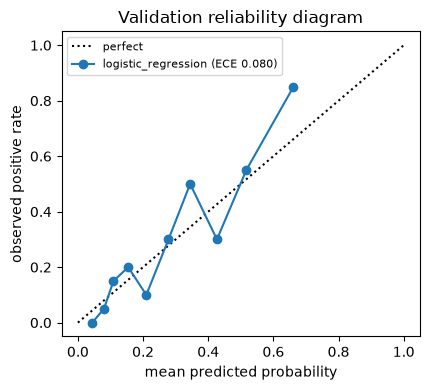

In [13]:
if IS_BINARY:
    observed, predicted = calibration_curve(y_val, val_proba, n_bins=10, strategy="quantile")
    bin_ids = np.clip(np.searchsorted(np.quantile(val_proba, np.linspace(0, 1, 11))[1:-1], val_proba, side="right"), 0, 9)
    ece = sum((bin_ids == b).mean() * abs(val_proba[bin_ids == b].mean() - y_val.to_numpy()[bin_ids == b].mean())
              for b in np.unique(bin_ids))
    base_rate = y_train.mean()
    brier, brier_base = brier_score_loss(y_val, val_proba), brier_score_loss(y_val, np.full(len(y_val), base_rate))
    print(f"validation ECE {ece:.3f} | Brier {brier:.4f} (predicting the base rate {base_rate:.2f} for everyone: {brier_base:.4f})")
    if ece <= 0.05:
        advice = "reasonably calibrated (ECE ≤ 0.05): probabilities can be read as risks"
    elif CONFIG["calibration"]:
        advice = (f"still miscalibrated (ECE > 0.05) with {CONFIG['calibration']} calibration: try the other method, more training rows, "
                  f"or accept it (a {len(y_val)}-row validation split makes ECE itself noisy)")
    else:
        advice = "noticeable miscalibration (ECE > 0.05): if probabilities are used downstream, set CONFIG['calibration'] and re-run from Step 9"
    print("→ " + advice)

    fig, ax = plt.subplots(figsize=(4.4, 4))
    ax.plot([0, 1], [0, 1], "k:", label="perfect")
    ax.plot(predicted, observed, "o-", label=f"{SELECTED} (ECE {ece:.3f})")
    ax.set(xlabel="mean predicted probability", ylabel="observed positive rate", title="Validation reliability diagram")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    val_pred = final_model.predict(X_val)
    print(f"validation RMSE {root_mean_squared_error(y_val, val_pred):.4f} | mean residual {np.mean(y_val - val_pred):+.4f} (≈ 0 means no systematic bias)")
    fig, ax = plt.subplots(figsize=(4.4, 4))
    ax.scatter(val_pred, y_val, s=8, alpha=0.5)
    lims = [min(val_pred.min(), y_val.min()), max(val_pred.max(), y_val.max())]
    ax.plot(lims, lims, "k:")
    ax.set(xlabel="predicted", ylabel="actual", title="Validation: predicted vs actual")
    plt.tight_layout()
    plt.show()

## 12. The Single Final Test Evaluation 🟡

Model, parameters, and threshold are now **frozen**. We score the test split **once** and report every number with a **95% bootstrap confidence interval**: resample the test rows with replacement 1,000 times, recompute the metric, and take the 2.5th and 97.5th percentiles. Small test sets give wide intervals, and that is exactly what a stakeholder needs to know.

If you re-run this cell after changing something upstream, the counter warns you: from then on the test score is no longer an unbiased estimate.

In [14]:
TEST_EVALUATIONS = globals().get("TEST_EVALUATIONS", 0) + 1
if TEST_EVALUATIONS > 1:
    print(f"⚠️ The test set has now been evaluated {TEST_EVALUATIONS} times in this session. Decisions made after looking at it bias it.")


def bootstrap(metric_fns: dict, y_true, pred, n_boot=CONFIG["n_bootstrap"], seed=SEED) -> pd.DataFrame:
    y_true, pred, rng = np.asarray(y_true), np.asarray(pred), np.random.default_rng(seed)
    rows = {name: [] for name in metric_fns}
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if IS_BINARY and y_true[idx].min() == y_true[idx].max():
            continue                                            # a resample with one class has no ROC-AUC
        for name, fn in metric_fns.items():
            rows[name].append(fn(y_true[idx], pred[idx]))
    return pd.DataFrame({name: {"estimate": fn(y_true, pred), "ci_low": np.percentile(rows[name], 2.5), "ci_high": np.percentile(rows[name], 97.5)}
                         for name, fn in metric_fns.items()}).T


if IS_BINARY:
    test_pred = final_model.predict_proba(X_test)[:, 1]                     # 🔓 the only time the test split is scored
    act_all_cost = lambda y, p: decision_cost(y, np.ones(len(y)))
    act_none_cost = lambda y, p: decision_cost(y, np.zeros(len(y)))
    metric_fns = {
        "roc_auc": roc_auc_score, "average_precision": average_precision_score, "brier": brier_score_loss,
        "cost_per_decision": lambda y, p: decision_cost(y, p >= THRESHOLD),
        "savings_vs_best_trivial": lambda y, p: min(act_all_cost(y, p), act_none_cost(y, p)) - decision_cost(y, p >= THRESHOLD),
        "precision_at_threshold": lambda y, p: (y[p >= THRESHOLD] == 1).mean() if (p >= THRESHOLD).any() else 0.0,
        "recall_at_threshold": lambda y, p: (p[y == 1] >= THRESHOLD).mean(),
    }
else:
    test_pred = final_model.predict(X_test)                                  # 🔓 the only time the test split is scored
    train_mean = y_train.mean()
    metric_fns = {"rmse": root_mean_squared_error, "mae": mean_absolute_error, "r2": r2_score,
                  "rmse_of_mean_baseline": lambda y, p: root_mean_squared_error(y, np.full(len(y), train_mean))}

start = time.perf_counter()
test_metrics = bootstrap(metric_fns, y_test, test_pred)
print(f"test rows: {len(y_test):,} | bootstrap: {time.perf_counter() - start:.1f} s\n")
print(test_metrics.round(4).to_string())

primary_name = {"roc_auc": "roc_auc", "average_precision": "average_precision", "neg_root_mean_squared_error": "rmse",
                "neg_mean_absolute_error": "mae", "r2": "r2"}.get(PRIMARY)
if primary_name in test_metrics.index:
    sign = -1 if PRIMARY.startswith("neg_") else 1
    cv_value = sign * cv_table.loc[SELECTED, f"{PRIMARY}_mean"]
    row = test_metrics.loc[primary_name]
    inside = row["ci_low"] <= cv_value <= row["ci_high"]
    print(f"\n{primary_name}: CV {cv_value:.4f} | test {row['estimate']:.4f} (95% CI {row['ci_low']:.4f}–{row['ci_high']:.4f}) → "
          + ("CV estimate is inside the test interval: consistent" if inside else "CV estimate is outside the test interval: investigate overfitting or drift between splits"))
if IS_BINARY:
    savings = test_metrics.loc["savings_vs_best_trivial"]
    print(f"savings vs the best trivial policy: {savings['estimate']:+.3f} per decision (95% CI {savings['ci_low']:+.3f} to {savings['ci_high']:+.3f}) → "
          + ("clearly better (CI excludes 0)" if savings["ci_low"] > 0 else "not clearly better (CI includes 0) — say so honestly"))

test rows: 200 | bootstrap: 0.8 s

                         estimate  ci_low  ci_high
roc_auc                    0.7770  0.7033   0.8420
average_precision          0.5609  0.4390   0.6853
brier                      0.1718  0.1444   0.1986
cost_per_decision          0.6200  0.5350   0.7100
savings_vs_best_trivial    0.0800 -0.0100   0.1501
precision_at_threshold     0.3372  0.2678   0.4035
recall_at_threshold        0.9667  0.9152   1.0000

roc_auc: CV 0.7667 | test 0.7770 (95% CI 0.7033–0.8420) → CV estimate is inside the test interval: consistent
savings vs the best trivial policy: +0.080 per decision (95% CI -0.010 to +0.150) → not clearly better (CI includes 0) — say so honestly


> 💡 **Interview angle:** "How confident are you in that test score?" — give the interval, not only the point estimate, and explain the test set was used once, after every choice was frozen.

## 13. Explainability: Permutation Importance 🟢

**Permutation importance** shuffles one raw column at a time on the **validation** split and measures how much the primary metric drops. It works for any model, and because it shuffles raw columns, a one-hot-encoded category counts as one feature.

Read it carefully: it shows what the **model relies on**, not what **causes** the outcome, and correlated columns share credit (shuffle one, the model leans on its twin, so both look unimportant).

permutation importance in 0.5 s
               feature  importance_mean  importance_std
       checking_status           0.0972          0.0236
               purpose           0.0394          0.0112
        savings_status           0.0313          0.0076
installment_commitment           0.0151          0.0119
                   age           0.0136          0.0113
        credit_history           0.0098          0.0095
       personal_status           0.0094          0.0085
               housing           0.0079          0.0020

5 of 20 features have zero or negative importance on validation (candidates to drop — confirm with CV first)


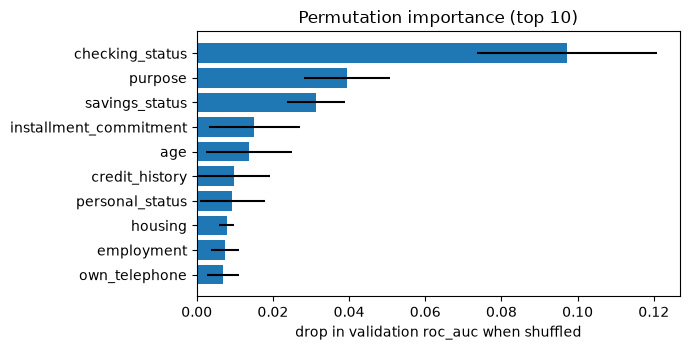

In [15]:
start = time.perf_counter()
importance = permutation_importance(final_model, X_val, y_val, scoring=PRIMARY, n_repeats=10, random_state=SEED)
importance_table = (pd.DataFrame({"feature": FEATURES, "importance_mean": importance.importances_mean, "importance_std": importance.importances_std})
                    .sort_values("importance_mean", ascending=False).reset_index(drop=True))
print(f"permutation importance in {time.perf_counter() - start:.1f} s")
print(importance_table.head(8).round(4).to_string(index=False))
n_useless = int((importance_table["importance_mean"] <= 0).sum())
print(f"\n{n_useless} of {len(FEATURES)} features have zero or negative importance on validation (candidates to drop — confirm with CV first)")

top = importance_table.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="tab:blue")
ax.set(xlabel=f"drop in validation {PRIMARY} when shuffled", title="Permutation importance (top 10)")
plt.tight_layout()
plt.show()

## 14. Save the Model With Metadata 🟢

A pickle alone is not a deployable model. Next to `model.joblib` we write `metadata.json`: version, data and split hashes, library versions, `CONFIG`, the input schema, the **threshold**, and all metrics. The service reads its threshold from this file, never from code, and reports the version in every response.

The version is `model_version+fingerprint`, where the fingerprint hashes the training data, model name, parameters, and threshold, so any change produces a new version.

⚠️ `joblib`/pickle files can run code when loaded: only load files you created. Load them with the **same scikit-learn version** (recorded below). For sharing across teams, look at `skops.io`.

In [16]:
ARTIFACTS = OUT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
fingerprint = hashlib.sha256(json.dumps({"train": SPLIT_HASHES["train"], "model": SELECTED, "params": best_params, "threshold": THRESHOLD,
                                          "calibration": CONFIG["calibration"]}, sort_keys=True, default=str).encode()).hexdigest()
example_input = {c: (None if pd.isna(v) else v.item() if hasattr(v, "item") else str(v) if c in CATEGORICAL else v)
                 for c, v in X_val.iloc[0].items()}                             # a validation row with exact floats (to_json rounds to 10 digits)
example_frame = X_val.head(1)
example_output = ({"probability": float(final_model.predict_proba(example_frame)[0, 1])} if IS_BINARY
                  else {"prediction": float(final_model.predict(example_frame)[0])})
input_schema = {c: {"kind": "number", "train_min": float(X_train[c].min()), "train_max": float(X_train[c].max())} for c in NUMERIC}
input_schema |= {c: {"kind": "category", "allowed": sorted(map(str, X_train[c].dropna().unique()))} for c in CATEGORICAL}

metadata = {
    "model_name": CONFIG["project_name"],
    "model_version": f"{CONFIG['model_version']}+{fingerprint[:8]}",
    "created_at": datetime.now(UTC).isoformat(timespec="seconds"),
    "task": CONFIG["task"], "target": TARGET, "positive_label": CONFIG["positive_label"] if IS_BINARY else None,
    "model_type": SELECTED, "selection_reason": SELECTION_REASON, "tuning": tuning_note,
    "params": {k: (v if isinstance(v, (int, float, str, bool, type(None))) else repr(v)) for k, v in best_params.items()},
    "calibration": CONFIG["calibration"],
    "threshold": THRESHOLD,
    "threshold_selection": (f"minimizes cost per decision on the validation split (c_FP={CONFIG['cost_false_positive']}, c_FN={CONFIG['cost_false_negative']})"
                            if IS_BINARY else None),
    "input_schema": input_schema, "feature_order": FEATURES,
    "example_input": example_input, "example_output": example_output,
    "data": {"sha256": DATA_SHA256, "rows": len(df), "split_strategy": CONFIG["split_strategy"],
             "splits": {name: {"rows": len(frame), "sha256": SPLIT_HASHES[name]} for name, frame in splits.items()}},
    "cross_validation": cv_table.reset_index().round(6).to_dict(orient="records"),
    "test_metrics": {name: {k: float(v) for k, v in row.items()} for name, row in test_metrics.iterrows()},
    "config": {k: str(v) for k, v in CONFIG.items()},
    "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
joblib.dump(final_model, ARTIFACTS / "model.joblib")
(ARTIFACTS / "metadata.json").write_text(json.dumps(metadata, indent=2, default=str))
for path in sorted(ARTIFACTS.iterdir()):
    print(f"{rel(path):45s} {path.stat().st_size / 1024:8.1f} KB")
print(json.dumps({k: metadata[k] for k in ["model_version", "model_type", "threshold", "calibration"]}, indent=1))

reloaded = joblib.load(ARTIFACTS / "model.joblib")
reloaded_pred = reloaded.predict_proba(X_test)[:, 1] if IS_BINARY else reloaded.predict(X_test)
assert np.allclose(reloaded_pred, test_pred)
print(f"✅ reloaded model reproduces all {len(X_test):,} test predictions")

_outputs/ml_template/artifacts/metadata.json       8.6 KB
_outputs/ml_template/artifacts/model.joblib        8.9 KB
{
 "model_version": "0.1.0+cf87298a",
 "model_type": "logistic_regression",
 "threshold": 0.09,
 "calibration": null
}
✅ reloaded model reproduces all 200 test predictions


## 15. FastAPI Service Stub and Its Tests 🟡

We write two small files to `_outputs/ml_template/service/` and run the tests with **pytest**:

- **`app.py`** — builds the request schema **from the metadata** with Pydantic v2 (`create_model`): numbers as floats, categories restricted to values seen in training, unknown fields rejected (`extra="forbid"`). The model loads once at startup (`lifespan`). Responses carry the probability, the decision, **the threshold from `metadata.json`**, and the model version.
- **`test_app.py`** — health check; the API's probability equals the offline pipeline's for the saved example row (catches training/serving skew); the threshold comes from metadata (the test changes it in a copy and checks the decision flips); invalid inputs get **422**.

TODO(you): tighten the schema by hand for production (numeric ranges with `Field(ge=..., le=...)`, required vs optional fields, a batch endpoint). The capstone's `churn_service/` shows a complete service with Docker and CI.

In [17]:
SERVICE = OUT / "service"
SERVICE.mkdir(exist_ok=True)

(SERVICE / "app.py").write_text(textwrap.dedent('''
    """Minimal prediction service generated by the ML template.

    Run:  MODEL_DIR=../artifacts uvicorn app:app --port 8000
    """
    import json
    import os
    from contextlib import asynccontextmanager
    from pathlib import Path
    from typing import Literal

    import joblib
    import pandas as pd
    from fastapi import FastAPI
    from pydantic import BaseModel, ConfigDict, Field, create_model

    DEFAULT_MODEL_DIR = Path(os.environ.get("MODEL_DIR", Path(__file__).resolve().parent.parent / "artifacts"))


    class Prediction(BaseModel):
        model_version: str
        prediction: float
        probability: float | None = None
        threshold: float | None = None


    def request_model(metadata: dict) -> type[BaseModel]:
        """Pydantic v2 model built from the saved input schema: typed fields, allowed categories, no unknown fields."""
        fields = {}
        for i, (column, spec) in enumerate(metadata["input_schema"].items()):
            kind = float if spec["kind"] == "number" else Literal[tuple(spec["allowed"])]
            fields[f"f{i}"] = (kind, Field(alias=column))          # aliases keep any column name valid
        return create_model("Features", __config__=ConfigDict(extra="forbid"), **fields)


    def create_app(model_dir: Path = DEFAULT_MODEL_DIR) -> FastAPI:
        metadata = json.loads((Path(model_dir) / "metadata.json").read_text())
        Features = request_model(metadata)
        state = {}

        @asynccontextmanager
        async def lifespan(app: FastAPI):
            state["model"] = joblib.load(Path(model_dir) / "model.joblib")   # load once, not per request
            yield
            state.clear()

        app = FastAPI(title=metadata["model_name"], version=metadata["model_version"], lifespan=lifespan)

        @app.get("/health")
        def health() -> dict:
            return {"status": "ok", "model_version": metadata["model_version"]}

        @app.post("/predict", response_model=Prediction)
        def predict(features: Features) -> Prediction:        # plain def: scikit-learn is CPU-bound, FastAPI runs it in a thread pool
            row = pd.DataFrame([features.model_dump(by_alias=True)])[metadata["feature_order"]]
            if metadata["task"] == "binary":
                probability = float(state["model"].predict_proba(row)[0, 1])
                threshold = metadata["threshold"]                        # from metadata.json, never hard-coded
                return Prediction(model_version=metadata["model_version"], prediction=float(probability >= threshold),
                                  probability=probability, threshold=threshold)
            return Prediction(model_version=metadata["model_version"], prediction=float(state["model"].predict(row)[0]))

        return app


    app = create_app()
''').lstrip())

(SERVICE / "test_app.py").write_text(textwrap.dedent('''
    import json
    import shutil

    import pytest
    from fastapi.testclient import TestClient

    from app import DEFAULT_MODEL_DIR, create_app

    METADATA = json.loads((DEFAULT_MODEL_DIR / "metadata.json").read_text())
    EXAMPLE = METADATA["example_input"]


    @pytest.fixture(scope="module")
    def client():
        with TestClient(create_app(DEFAULT_MODEL_DIR)) as test_client:
            yield test_client


    def test_health_reports_model_version(client):
        response = client.get("/health")
        assert response.status_code == 200
        assert response.json()["model_version"] == METADATA["model_version"]


    def test_prediction_matches_offline_pipeline(client):
        body = client.post("/predict", json=EXAMPLE).json()
        assert body["model_version"] == METADATA["model_version"]
        key = "probability" if METADATA["task"] == "binary" else "prediction"
        assert body[key] == pytest.approx(METADATA["example_output"][key], rel=1e-9, abs=1e-9)


    @pytest.mark.skipif(METADATA["task"] != "binary", reason="thresholds only exist for binary tasks")
    def test_threshold_is_read_from_metadata(client, tmp_path):
        body = client.post("/predict", json=EXAMPLE).json()
        assert body["threshold"] == METADATA["threshold"]
        assert body["prediction"] == float(body["probability"] >= METADATA["threshold"])
        shutil.copy(DEFAULT_MODEL_DIR / "model.joblib", tmp_path / "model.joblib")
        flipped = body["probability"] + (1e-6 if body["prediction"] == 1.0 else -1e-6)   # a threshold that flips this decision
        (tmp_path / "metadata.json").write_text(json.dumps({**METADATA, "threshold": flipped}))
        with TestClient(create_app(tmp_path)) as other:
            other_body = other.post("/predict", json=EXAMPLE).json()
        assert other_body["threshold"] == pytest.approx(flipped)
        assert other_body["prediction"] != body["prediction"]


    def test_unknown_field_is_rejected(client):
        assert client.post("/predict", json={**EXAMPLE, "unexpected": 1}).status_code == 422


    def test_missing_field_is_rejected(client):
        incomplete = dict(EXAMPLE)
        incomplete.pop(next(iter(incomplete)))
        assert client.post("/predict", json=incomplete).status_code == 422


    def test_wrong_types_and_unknown_categories_are_rejected(client):
        schema = METADATA["input_schema"]
        numeric = [c for c, s in schema.items() if s["kind"] == "number"]
        categorical = [c for c, s in schema.items() if s["kind"] == "category"]
        if numeric:
            assert client.post("/predict", json={**EXAMPLE, numeric[0]: "not a number"}).status_code == 422
        if categorical:
            assert client.post("/predict", json={**EXAMPLE, categorical[0]: "__never_seen__"}).status_code == 422
''').lstrip())

(SERVICE / "pytest.ini").write_text(textwrap.dedent('''
    [pytest]
    filterwarnings =
        error::DeprecationWarning:app
        # third-party: Starlette's TestClient touches an alias that anyio deprecated (not fixable in this project)
        ignore:The anyio.abc.BlockingPortal alias is deprecated:DeprecationWarning
''').lstrip())

start = time.perf_counter()
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider", "test_app.py"], cwd=SERVICE,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, timeout=300)
print(f"$ cd {rel(SERVICE)} && python -m pytest -q test_app.py")
print(textwrap.indent(rel(result.stdout.strip()), "  "))
print(f"  [exit code {result.returncode} · {time.perf_counter() - start:.1f} s]")
assert result.returncode == 0, "service tests failed"
print("✅ service tests passed")

$ cd _outputs/ml_template/service && python -m pytest -q test_app.py
  ......                                                                   [100%]
  6 passed in 0.91s
  [exit code 0 · 1.5 s]
✅ service tests passed


> 💡 **Interview angle:** "How do you know the API serves the model you evaluated?" — the service loads the saved pipeline and metadata, returns the model version with every response, reads the threshold from metadata, and a test asserts the API output equals the offline prediction for the same row.

## 16. Optional MLflow Logging 🟢

**MLflow** records runs (parameters, metrics, files) so you can compare experiments and trace a deployed model back to its data and code. This cell runs only if `CONFIG["use_mlflow"]` is `True` **and** MLflow is installed; otherwise it prints why it skipped. The store is a local SQLite file in `_outputs/`; browse it with `mlflow ui --backend-store-uri sqlite:///_outputs/ml_template/mlflow/mlflow.db`.

TODO(you): point `MLFLOW_TRACKING_URI` at your team's tracking server and register the model in the Model Registry.

In [18]:
if not CONFIG["use_mlflow"]:
    print("⏭️ Skipped MLflow logging: CONFIG['use_mlflow'] is False.")
elif not HAS_MLFLOW:
    print("⏭️ Skipped MLflow logging: mlflow is not installed (pip install 'mlflow>=3.16,<4').")
else:
    import mlflow
    logging.getLogger("mlflow").setLevel(logging.WARNING)        # hide INFO lines such as database migrations
    mlflow_dir = (OUT / "mlflow").resolve()
    mlflow_dir.mkdir(exist_ok=True)
    mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", f"sqlite:///{mlflow_dir / 'mlflow.db'}"))
    if mlflow.get_experiment_by_name(CONFIG["project_name"]) is None:
        mlflow.create_experiment(CONFIG["project_name"], artifact_location=(mlflow_dir / "artifacts").as_uri())
    mlflow.set_experiment(CONFIG["project_name"])
    with mlflow.start_run(run_name=metadata["model_version"]) as run:
        mlflow.set_tags({"model_type": SELECTED, "split_strategy": CONFIG["split_strategy"], "data_sha256": DATA_SHA256[:16]})
        mlflow.log_params({"model_type": SELECTED, "threshold": THRESHOLD, "calibration": CONFIG["calibration"], **best_params})
        mlflow.log_metrics({f"cv_{m}": float(cv_table.loc[SELECTED, f"{m}_mean"]) for m in SCORING})
        mlflow.log_metrics({f"test_{name}": float(row["estimate"]) for name, row in test_metrics.iterrows()})
        mlflow.log_artifacts(str(ARTIFACTS), artifact_path="model_bundle")
    logged = mlflow.get_run(run.info.run_id)
    print(f"✅ logged run {run.info.run_id[:8]}… to experiment '{CONFIG['project_name']}': "
          f"{len(logged.data.params)} params, {len(logged.data.metrics)} metrics, bundle files: "
          f"{[a.path for a in mlflow.MlflowClient().list_artifacts(run.info.run_id, 'model_bundle')]}")

✅ logged run 39bcc73c… to experiment 'credit_risk': 4 params, 11 metrics, bundle files: ['model_bundle/metadata.json', 'model_bundle/model.joblib']


## ✅ Checklist

Tick every box before anyone relies on the model. Unticked boxes go into the model card as known limitations.

**Problem and data**
- [ ] The decision the model supports, and who acts on it, is written down.
- [ ] Success criteria (metric **and** business target) were set before modelling.
- [ ] Every feature is available **at prediction time** in production (no post-outcome columns).
- [ ] Schema checks pass; warnings were read and resolved or documented.

**Splits and leakage**
- [ ] `split_strategy` matches reality: `group` for repeated entities, `time` for forecasting the future.
- [ ] All learned preprocessing is inside the pipeline; nothing was fitted on validation or test rows.
- [ ] The leakage scan shows no suspiciously predictive single column (or it is explained).

**Modelling**
- [ ] The chosen model clearly beats the dummy baseline.
- [ ] Model choice used CV on training data only; the simpler model won ties.
- [ ] Tuning (if any) used CV on training data and kept defaults when it didn't help.
- [ ] For multiclass problems: stratified split, macro-averaged metrics, per-class thresholds or none (this template covers binary and regression).

**Decision and evaluation**
- [ ] The threshold came from business costs on the **validation** split and is saved in metadata.
- [ ] Calibration was checked; probabilities are calibrated if anyone reads them.
- [ ] The test set was evaluated **once**; metrics are reported with confidence intervals.
- [ ] Performance was checked on important slices (regions, customer types, protected groups).

**Shipping**
- [ ] Model + metadata (version, data hash, params, threshold, metrics, library versions) are saved together.
- [ ] The service reads the threshold and version from metadata; tests cover skew and invalid inputs.
- [ ] Library versions are pinned (lock file) and the model loads with the same scikit-learn version.
- [ ] A monitoring plan exists: input drift, prediction drift, and delayed-label performance, with a retraining trigger.

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html) — data leakage and preprocessing inside pipelines
- [scikit-learn — Cross-validation: evaluating estimator performance](https://scikit-learn.org/stable/modules/cross_validation.html) — `GroupKFold`, `TimeSeriesSplit`, and friends
- [scikit-learn — Tuning the decision threshold](https://scikit-learn.org/stable/modules/classification_threshold.html) — `TunedThresholdClassifierCV` and cost-sensitive thresholds
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — reliability diagrams, sigmoid vs isotonic
- [scikit-learn — Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html) — including the correlated-features caveat
- [Optuna documentation](https://optuna.readthedocs.io/en/stable/) — define-by-run search spaces and samplers
- [FastAPI — Testing](https://fastapi.tiangolo.com/tutorial/testing/) — `TestClient` with pytest
- [MLflow — Tracking](https://mlflow.org/docs/latest/ml/tracking/) — runs, parameters, metrics, and artifacts

### 🎥 Videos
- [StatQuest — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (~16 min) — what the primary metric measures and how thresholds trade errors
- [StatQuest — Bootstrapping Main Ideas!!!](https://www.youtube.com/watch?v=Xz0x-8-cgaQ) (~9 min) — the idea behind the Step 12 confidence intervals

### 📄 Papers
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html) — why the model is the smallest part of an ML system
- [Mitchell et al. (2019) — Model Cards for Model Reporting](https://arxiv.org/abs/1810.03993) — what to write down next to the metadata

### 📘 Books & Worked Examples
- [End-to-End ML Project (this course)](../13_Capstone_Projects/01_End_to_End_ML_Project.ipynb) — this template filled in: profit-based threshold, package, Docker, CI, monitoring
- [Google — Rules of Machine Learning](https://developers.google.com/machine-learning/guides/rules-of-ml) — practical advice on metrics, pipelines, and training/serving skew
- [OpenML — German Credit (credit-g)](https://www.openml.org/d/31) — the example dataset and its cost matrix

## ➡️ What's Next

**[02 · Deep Learning Template](02_DL_Template.ipynb)** — the same copy-and-fill discipline for PyTorch projects: saved splits, a training loop with early stopping and checkpoints, calibration, error analysis, and `torch.export`.